# OD criticality - travel-time routing with stochastic assignment

An alternative to the RA2CE routing step in `pipeline.py --stages route`. The RA2CE method and its
outputs are left exactly as they are; everything here writes to `output/od_stochastic/`.

## Why

The RA2CE run routes every origin on **shortest distance**, and the graph carries no road hierarchy:
all 81,161 OD-graph edges have `highway = None` and `avgspeed = 50` (RA2CE looks for a `highway` field;
the Overture network calls it `class`). So a residential block costs the same per metre as a collector
or Lake Tahoe Blvd. In a street grid dozens of staircase paths are within a few metres of each other,
Dijkstra deterministically picks one, and every origin upstream shares that path tree. In Al Tahoe that
put the neighbourhood's evacuation traffic on a chain of residential blocks through Osborne Ave while
Sierra Blvd and Barbara Ave (both `tertiary`) carried almost nothing.

## Method

1. **Travel-time cost.** Each segment gets a free-flow speed from its road class (`SPEED_MPH`). An OD
   edge's time is the sum over the Overture segments it covers (`rfid_c`), so a chain that mixes classes
   is costed correctly.
2. **Stochastic assignment.** The routing is repeated `N_DRAWS` times. In each draw every edge's time is
   multiplied by an independent lognormal factor with mean 1 and coefficient of variation ~`SIGMA`, and
   the traffic is averaged over the draws. Paths that are near-ties share the load; a clearly faster
   route (a collector, a highway) still wins nearly every draw. Destination choice is re-made in each
   draw on the perturbed times, so co-located facilities share catchments too.
3. **Everything else is unchanged**: the same per-analysis OD graphs (archived from the 2026-09-16 run),
   origin snapping, `POPULATION`, block-group equity weights (1 + normalised poverty rate), destination
   rule (`nearest` for evacuation and law enforcement, `gravity` beta = 2 for medical and shelters), and
   the same output schema, so the combine / PROTECT_VA steps work unchanged.

The router is scipy's Dijkstra run from the destinations: one shortest-path tree per destination covers
every origin at once, and traffic is accumulated down the tree. A full 100-draw run of all four
analyses takes a few minutes rather than the ~4.5 h of RA2CE's per-pair routing.

**Reading `traffic` totals.** Summed street traffic is not conserved between methods: a trip spread over
two parallel streets is counted on both. Compare methods on person-km or per-street values, not on totals.

## Validation

Before anything else the router is run in RA2CE's own configuration (distance cost, no noise) and
compared to the RA2CE results. **Person-km** (population x route length, summed) does not depend on how
equal-length ties are broken, so it must match; segment-level traffic can differ only where RA2CE and
scipy broke a tie differently.

**Kernel:** `arcgispro-py3-plotly`.

In [1]:
import ast
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import pyogrio
import shapely
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix, coo_matrix
from scipy.sparse.csgraph import dijkstra

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## 1. Configuration

In [2]:
HERE = Path.cwd() if (Path.cwd() / "pipeline.py").exists() else Path.cwd() / "scripts" / "ra2ce_v2"
ODR = HERE / "output" / "optimal_route_origin_destination"   # RA2CE run: inputs + baseline (read only)
NET = HERE / "static" / "network"
OUT = HERE / "output" / "od_stochastic"                       # everything this notebook writes
OUT.mkdir(parents=True, exist_ok=True)

# published field suffix -> (RA2CE analysis name, destination choice)
ANALYSES = {
    "evacuation":         ("tahoe_od_evacuation",          "nearest"),
    "law_enforcement":    ("tahoe_od_locallawenforcement", "nearest"),
    "medical_facilities": ("tahoe_od_medicalfacilities",   "gravity"),
    "emergency_shelters": ("tahoe_od_evacuationshelters",  "gravity"),
}
GRAVITY_BETA = 2.0          # as in nb_helpers.GRAVITY_BETA

# Free-flow speed by Overture road class (mph). Starting assumptions - calibrate with TRPA.
SPEED_MPH = {
    "motorway": 55, "trunk": 45, "primary": 35, "secondary": 30, "tertiary": 30,
    "unclassified": 25, "residential": 25, "living_street": 10, "service": 10, "unknown": 15,
}
DEFAULT_MPH = 25

N_DRAWS = 100               # stochastic draws per analysis
SIGMA = 0.25                # lognormal sigma of the per-edge time multiplier (CV ~25%)
SEED = 20261008

## 2. Segment speeds

RA2CE dropped the road class, so it is recovered from the split network the graph was built from.
`base_network.feather` rows are matched to `overture_split.shp` features on exact geometry (normalised,
1e-7 degree precision): all 97,814 match. Segment length is measured in a metric CRS (EPSG:3310).

In [3]:
bn = gpd.read_feather(ODR / "tahoe_od_evacuation_graph" / "base_network.feather").set_crs(4326, allow_override=True)
split = pyogrio.read_dataframe(NET / "overture_split.shp", columns=["class", "name"]).to_crs(4326)

def geom_key(g):
    return shapely.to_wkb(shapely.normalize(shapely.set_precision(shapely.force_2d(g), 1e-7)), hex=True)

lookup = pd.DataFrame({"class": split["class"].to_numpy(), "name": split["name"].to_numpy()},
                      index=geom_key(split.geometry.values))
assert lookup.index.is_unique
seg = pd.DataFrame({"rfid_c": bn.rfid_c.astype(int).to_numpy()})
seg[["class", "name"]] = lookup.reindex(geom_key(bn.geometry.values)).to_numpy()
assert seg["class"].notna().all(), f"{seg['class'].isna().sum()} segments without a class"
seg["len_m"] = bn.to_crs(3310).length.to_numpy()
seg["mph"] = seg["class"].map(SPEED_MPH).fillna(DEFAULT_MPH)
seg["time_s"] = seg.len_m / (seg.mph * 0.44704)
seg = seg.set_index("rfid_c")
print(f"{len(seg):,} segments; speed by class:")
seg.groupby("class").agg(segments=("mph", "size"), mph=("mph", "first"), km=("len_m", lambda s: s.sum() / 1000)).round(0)

97,814 segments; speed by class:


,segments,mph,km
class,,,
living_street,48,10,4.0
motorway,449,55,283.0
primary,2929,35,488.0
residential,29961,25,3059.0
secondary,3444,30,433.0
service,49084,10,2841.0
tertiary,5884,30,607.0
trunk,1102,45,185.0
unclassified,4125,25,902.0


## 3. Router

* `load_analysis` - the archived OD graph edges, origin populations and equity weights, and the
  origin / destination nodes from RA2CE's route table. Equity weights are rebuilt exactly as
  `run_od_analysis` does (block group `within`, unweighted regions -> 1.0).
* `assign` - one routing pass for a given edge cost: Dijkstra trees from the destinations, destination
  choice (`nearest` or `gravity`), traffic pushed down each tree. Parallel edges between the same node
  pair: the cheapest one in that pass carries the flow.
* `run_analysis` - `N_DRAWS` passes with lognormal noise, averaged.

In [4]:
def rfid_list(v):
    if isinstance(v, (list, tuple)):
        return [int(x) for x in v]
    if isinstance(v, str) and v.strip().startswith("["):
        return [int(x) for x in ast.literal_eval(v)]
    try:
        return [int(float(v))]
    except (TypeError, ValueError):
        return []


def equity_weights(disk_name, od_table):
    """o_id -> weight, replicating run_od_analysis (blockgroup.shp + blockgroup_weights.csv)."""
    weights = pd.read_csv(NET / "blockgroup_weights.csv")
    regions = gpd.read_file(NET / "blockgroup.shp")
    rcol = next(c for c in regions.columns if "region" in c.lower() and c != regions.geometry.name)
    orig = gpd.read_file(NET / f"{disk_name}_origins.shp")
    regions = regions.to_crs(orig.crs)
    sj = gpd.sjoin(orig[[orig.geometry.name]], regions[[rcol, regions.geometry.name]],
                   how="left", predicate="within")
    sj = sj[~sj.index.duplicated(keep="first")]
    o2r = {f"O_{i}": str(r) for i, r in sj[rcol].items() if pd.notna(r)}
    w = dict(zip(weights["region"], weights["weight"]))
    return {o: float(w.get(o2r.get(o), 1.0)) for o in od_table["o_id"]}


def load_analysis(disk_name):
    gdir = ODR / f"{disk_name}_graph"
    e = pyogrio.read_dataframe(gdir / "origins_destinations_graph_edges.gpkg",
                               columns=["u", "v", "rfid_c", "length"], read_geometry=False)
    e["segs"] = e["rfid_c"].map(rfid_list)
    # time = the edge's own length at the length-weighted pace of the segments it covers;
    # snapping splits edges, so a piece covers part of its segments and its own length is the truth
    ex = e[["segs"]].explode("segs").dropna()
    ex = ex.join(seg[["len_m", "time_s"]], on=ex["segs"].astype(int))
    agg = ex.groupby(level=0)[["len_m", "time_s"]].sum()
    pace = (agg.time_s / agg.len_m).reindex(e.index)
    pace = pace.fillna(1 / (DEFAULT_MPH * 0.44704))
    e["time_s"] = e["length"] * pace

    nodes, inv = np.unique(np.concatenate([e.u.to_numpy(), e.v.to_numpy()]), return_inverse=True)
    e["ui"], e["vi"] = inv[:len(e)], inv[len(e):]
    node_ix = pd.Series(np.arange(len(nodes)), index=nodes)

    routes = pyogrio.read_dataframe(ODR / f"{disk_name}.gpkg", read_geometry=False,
                                    columns=["o_node", "d_node", "origin", "destination", "length"])
    od_table = pd.read_feather(gdir / "origin_destination_table.feather")
    od_table = od_table[od_table["o_id"].notna()]          # destination rows carry d_id only
    pop =od_table.set_index("o_id")["POPULATION"].fillna(0).astype(float)
    wt = pd.Series(equity_weights(disk_name, od_table))

    o = routes.drop_duplicates("origin")[["origin", "o_node"]]
    o = o[o.origin.isin(pop.index)]
    d = routes.drop_duplicates("destination")[["destination", "d_node"]].reset_index(drop=True)
    return dict(edges=e, n=len(nodes),
                o_ix=node_ix.reindex(o.o_node).to_numpy(), o_id=o.origin.to_numpy(),
                pop=pop.reindex(o.origin).to_numpy(), wt=wt.reindex(o.origin).fillna(1.0).to_numpy(),
                d_ix=node_ix.reindex(d.d_node).to_numpy(), d_id=d.destination.to_numpy(),
                routes=routes)


def cheapest_parallel(ui, vi, w):
    """Index of the cheapest edge per undirected node pair (self-loops dropped)."""
    a, b = np.minimum(ui, vi), np.maximum(ui, vi)
    keep = a != b
    idx = np.flatnonzero(keep)
    order = idx[np.lexsort((w[idx], b[idx], a[idx]))]
    first = np.ones(len(order), bool)
    first[1:] = (a[order][1:] != a[order][:-1]) | (b[order][1:] != b[order][:-1])
    return order[first]


def push_down_tree(dist, pred, loads):
    """Accumulate node loads toward the tree root; returns the load leaving each node."""
    reach = np.flatnonzero(np.isfinite(dist) & (pred >= 0))
    order = reach[np.argsort(-dist[reach], kind="stable")]
    L = [col.tolist() for col in loads]       # python lists: fast scalar access
    P = pred.tolist()
    L0, L1, L2 = L
    for n in order:
        if L1[n] == 0.0:
            continue
        p = P[n]
        L0[p] += L0[n]; L1[p] += L1[n]; L2[p] += L2[n]
    return np.array(L), order


def assign(A, w, mode):
    """One routing pass.

    Returns (flows, cost, check):
      flows - per-edge [traffic, egalitarian, prioritarian]
      cost  - person-cost (population x route cost)
      check - per destination: trips sent there (population x share) and trips that arrive at its
              node after being pushed down the shortest-path tree. They must be equal.
    """
    e, n = A["edges"], A["n"]
    ui, vi = e.ui.to_numpy(), e.vi.to_numpy()
    best = cheapest_parallel(ui, vi, w)
    rows = np.concatenate([ui[best], vi[best]])
    cols = np.concatenate([vi[best], ui[best]])
    G = csr_matrix((np.concatenate([w[best], w[best]]), (rows, cols)), shape=(n, n))
    E = csr_matrix((np.concatenate([best, best]) + 1, (rows, cols)), shape=(n, n))  # pair -> edge id+1

    flows = np.zeros((3, len(e)))
    o_ix, pop, wt = A["o_ix"], A["pop"], A["wt"]

    def add_tree(dist, pred, share):
        loads = np.zeros((3, n))
        np.add.at(loads[0], o_ix, share * pop)
        np.add.at(loads[1], o_ix, share)
        np.add.at(loads[2], o_ix, share * pop * wt)
        L, order = push_down_tree(dist, pred, loads)
        ch = order[L[1, order] > 0]
        eid = np.asarray(E[ch, pred[ch]]).ravel() - 1
        flows[:, eid] += L[:, ch]
        return L[0]                     # population load at every node; roots hold what arrived

    d_ix = A["d_ix"]
    if mode == "nearest":
        dist, pred, src = dijkstra(G, indices=d_ix, min_only=True, return_predecessors=True)
        share = np.isfinite(dist[o_ix]).astype(float)
        L0 = add_tree(dist, pred, share)
        cost = float(np.nansum(np.where(share > 0, dist[o_ix], 0) * pop))
        # destinations sharing a node are one root; count each node once
        sent = np.array([float((share * pop)[src[o_ix] == d].sum()) for d in d_ix])
        arrived = L0[d_ix]
        first = ~pd.Series(d_ix).duplicated().to_numpy()
        sent, arrived = np.where(first, sent, 0.0), np.where(first, arrived, 0.0)
    else:
        dists, preds = dijkstra(G, indices=d_ix, return_predecessors=True)
        t = np.clip(dists[:, o_ix], 1.0, None)                 # (n_dest, n_origin)
        inv = np.where(np.isfinite(t), t ** (-GRAVITY_BETA), 0.0)
        tot = inv.sum(axis=0)
        shares = np.divide(inv, tot, out=np.zeros_like(inv), where=tot > 0)
        sent, arrived = np.zeros(len(d_ix)), np.zeros(len(d_ix))
        for k in range(len(d_ix)):
            L0 = add_tree(dists[k], preds[k], shares[k])
            sent[k] = float((shares[k] * pop).sum())
            arrived[k] = L0[d_ix[k]]
        cost = float(np.nansum(np.where(shares > 0, t, 0) * shares * pop))
    check = dict(sent=sent, arrived=arrived, reachable_pop=float(pop[np.isfinite(
        dist[o_ix] if mode == "nearest" else dists[:, o_ix].min(axis=0))].sum()))
    return flows, cost, check


def run_analysis(A, base_cost, mode, n_draws, sigma, seed, checks=None):
    """N noisy passes, averaged. Each pass's trip check is appended to `checks` if given."""
    rng = np.random.default_rng(seed)
    s = np.zeros((3, len(A["edges"])))
    s2 = np.zeros(len(A["edges"]))
    for _ in range(n_draws):
        noise = np.exp(rng.normal(-sigma ** 2 / 2, sigma, len(base_cost))) if sigma > 0 else 1.0
        f, _, chk = assign(A, base_cost * noise, mode)
        if checks is not None:
            checks.append(chk)
        s += f
        s2 += f[0] ** 2
    mean = s / n_draws
    sd = np.sqrt(np.maximum(s2 / n_draws - mean[0] ** 2, 0))
    return mean, sd

## 4. Validation against RA2CE

Distance cost, no noise, one pass - RA2CE's own configuration. Person-km from the router is compared to
the RA2CE route table (each origin's population times the length of the route(s) it was assigned,
using the same `nearest` / `gravity` shares). Segment traffic is then compared to the RA2CE criticality
layer.

In [5]:
def to_segments(A, flows):
    """Edge flows -> complex segments (max over the edges naming a segment), as join_traffic_to_network."""
    e = A["edges"]
    ex = pd.DataFrame({"segs": e["segs"], "t": flows[0], "g": flows[1], "p": flows[2]}).explode("segs").dropna()
    ex["segs"] = ex["segs"].astype(int)
    return ex.groupby("segs")[["t", "g", "p"]].max()


def ra2ce_person_km(A, mode):
    r = A["routes"].dropna(subset=["length"])
    r = r[r.origin.isin(A["o_id"])]
    pop = pd.Series(A["pop"], index=A["o_id"])
    if mode == "nearest":
        r = r.loc[r.groupby("origin")["length"].idxmin()]
        return float((r["length"] * r["origin"].map(pop)).sum())
    d = np.clip(r["length"].to_numpy(), 1.0, None)
    inv = pd.Series(d ** (-GRAVITY_BETA), index=r.index)
    share = inv / inv.groupby(r["origin"]).transform("sum")
    return float((share * r["length"] * r["origin"].map(pop)).sum())


DATA, VALID = {}, []
for suffix, (disk, mode) in ANALYSES.items():
    t0 = time.time()
    A = DATA[suffix] = load_analysis(disk)
    flows, pk, _ = assign(A, A["edges"]["length"].to_numpy(dtype=float), mode)
    ref = ra2ce_person_km(A, mode)
    mine = to_segments(A, flows)["t"]
    old = gpd.read_file(ODR / f"{disk}_criticality.gpkg", ignore_geometry=True).set_index("rfid_c")["traffic"]
    both = pd.concat([mine.rename("router"), old.rename("ra2ce")], axis=1).fillna(0)
    VALID.append(dict(analysis=suffix, mode=mode, origins=len(A["o_id"]), destinations=len(A["d_id"]),
                      person_km_router=pk / 1000, person_km_ra2ce=ref / 1000,
                      person_km_diff_pct=100 * (pk - ref) / ref,
                      segment_corr=both.corr().iloc[0, 1],
                      segments_within_1pct=(np.isclose(both.router, both.ra2ce, rtol=0.01, atol=0.5)).mean(),
                      seconds=time.time() - t0))
valid = pd.DataFrame(VALID).round(4)
valid

,analysis,mode,origins,destinations,person_km_router,person_km_ra2ce,person_km_diff_pct,segment_corr,segments_within_1pct,seconds
0,evacuation,nearest,2195,7,564773.4880,564773.4880,0.0,1.0000,0.9995,14.7347
1,law_enforcement,nearest,2195,7,209761.2154,209761.2154,0.0,0.9998,0.9994,13.6032
2,medical_facilities,gravity,2195,5,432107.0162,432107.0162,0.0,0.9999,0.9988,9.1491
3,emergency_shelters,gravity,2195,9,313951.4543,313951.4543,0.0,0.9996,0.9986,17.0195


## 5. Travel-time routing + stochastic assignment

Two runs per analysis, so the effect of each change is visible on its own:

* `time` - travel-time cost, one deterministic pass;
* `stochastic` - travel-time cost, `N_DRAWS` noisy passes averaged (the result carried forward).

A convergence check splits the draws in half: if the two half-means agree closely, `N_DRAWS` is enough.

In [6]:
RESULTS = {}
for i, (suffix, (disk, mode)) in enumerate(ANALYSES.items()):
    A = DATA[suffix]
    tcost = A["edges"]["time_s"].to_numpy(dtype=float)
    t0 = time.time()
    det, _, det_chk = assign(A, tcost, mode)
    n1, n2 = N_DRAWS // 2, N_DRAWS - N_DRAWS // 2
    checks = []
    h1, sd1 = run_analysis(A, tcost, mode, n1, SIGMA, SEED + 10 * i, checks)
    h2, sd2 = run_analysis(A, tcost, mode, n2, SIGMA, SEED + 10 * i + 1, checks)
    mean = (h1 * n1 + h2 * n2) / N_DRAWS
    # pooled draw-to-draw standard deviation of edge traffic
    ex2 = (n1 * (sd1 ** 2 + h1[0] ** 2) + n2 * (sd2 ** 2 + h2[0] ** 2)) / N_DRAWS
    sd = np.sqrt(np.maximum(ex2 - mean[0] ** 2, 0))
    RESULTS[suffix] = dict(det=det, mean=mean, sd=sd, half1=h1, half2=h2,
                           checks=checks, det_check=det_chk)
    s1, s2 = to_segments(A, h1)["t"], to_segments(A, h2)["t"]
    big = (s1 + s2) / 2 > 100
    print(f"{suffix:<20} {time.time() - t0:5.0f}s  half-sample agreement on segments >100: "
          f"corr {np.corrcoef(s1[big], s2[big])[0, 1]:.4f}, "
          f"median abs gap {np.median(np.abs(s1[big] - s2[big]) / ((s1[big] + s2[big]) / 2)) * 100:.1f}%")

evacuation               7s  half-sample agreement on segments >100: corr 0.9992, median abs gap 2.9%


law_enforcement          8s  half-sample agreement on segments >100: corr 0.9994, median abs gap 2.8%


medical_facilities      25s  half-sample agreement on segments >100: corr 0.9990, median abs gap 1.9%


emergency_shelters      42s  half-sample agreement on segments >100: corr 0.9989, median abs gap 2.0%


## 6. Trip conservation check

Spreading must move trips between streets, never create or lose them. In every routing pass (the
deterministic one and all `N_DRAWS` noisy ones) the router records, for each destination:

* **sent** - trips assigned to that destination: each origin's population x its share for it
  (1 or 0 under `nearest`, the gravity share otherwise);
* **arrived** - trips that reach the destination's node after being pushed down its shortest-path tree.

They must agree in every pass, and the total sent must equal the population of every origin that can
reach a destination. The second table shows the average trips arriving at each destination, with no
spreading and with it: under `gravity` and stochastic destination choice, trips can shift between
co-located facilities, but the total cannot change.

This is also why summed street `traffic` is not a trip count: a trip adds its population to every
segment it crosses, so that sum scales with how many segments the routes pass through. Trips are
conserved; segment crossings are not.

In [7]:
def destination_names(disk):
    """D_<i> -> facility name; D_<i> is row i of the prepared destinations file, as RA2CE numbers them."""
    p = NET / f"{disk}_destinations.shp"
    if not p.exists():
        return {}
    g = pyogrio.read_dataframe(p, read_geometry=False)
    col = next((c for c in g.columns if c.lower() in ("name", "facility", "fac_name", "label")), None)
    return {f"D_{i}": str(n) for i, n in enumerate(g[col])} if col else {}

rows, per_dest = [], []
for suffix, (disk, mode) in ANALYSES.items():
    A, R = DATA[suffix], RESULTS[suffix]
    all_checks = [R["det_check"]] + R["checks"]
    sent = np.array([c["sent"] for c in all_checks])          # (passes, destinations)
    arrived = np.array([c["arrived"] for c in all_checks])
    reach = np.array([c["reachable_pop"] for c in all_checks])
    rows.append(dict(analysis=suffix, mode=mode, passes_checked=len(all_checks),
                     population_reachable=reach[0],
                     trips_sent_per_pass=sent.sum(axis=1).mean(),
                     trips_arrived_per_pass=arrived.sum(axis=1).mean(),
                     max_abs_gap_any_destination=float(np.abs(sent - arrived).max()),
                     max_gap_sent_vs_population=float(np.abs(sent.sum(axis=1) - reach).max())))
    names = destination_names(disk)
    for k, d in enumerate(A["d_id"]):
        per_dest.append(dict(analysis=suffix, destination=d, name=names.get(d, d),
                             arrived_time_only=arrived[0, k], arrived_stochastic_mean=arrived[1:, k].mean()))

conservation = pd.DataFrame(rows).round(6)
assert (conservation.max_abs_gap_any_destination < 1e-6).all(), "trips lost or created at a destination"
assert (conservation.max_gap_sent_vs_population < 1e-6).all(), "trips sent differ from reachable population"
print("PASS: in every pass, trips arriving at each destination equal trips sent to it, "
      "and trips sent equal the reachable population")
conservation

PASS: in every pass, trips arriving at each destination equal trips sent to it, and trips sent equal the reachable population


,analysis,mode,passes_checked,population_reachable,trips_sent_per_pass,trips_arrived_per_pass,max_abs_gap_any_destination,max_gap_sent_vs_population
0,evacuation,nearest,101,53933.0,53933.0,53933.0,0.0,0.0
1,law_enforcement,nearest,101,53933.0,53933.0,53933.0,0.0,0.0
2,medical_facilities,gravity,101,53933.0,53933.0,53933.0,0.0,0.0
3,emergency_shelters,gravity,101,53933.0,53933.0,53933.0,0.0,0.0


In [8]:
pd.DataFrame(per_dest).round(1).set_index(["analysis", "destination"])

name  arrived_time_only  arrived_stochastic_mean
analysis           destination                                                                                               
evacuation         D_0                                                        D_0            20603.0                  20055.1
                   D_1                                                        D_1               38.0                     77.6
                   D_2                                                        D_2            13513.0                  14032.1
                   D_3                                                        D_3             1127.0                   1115.8
                   D_4                                                        D_4             8821.0                   8202.1
                   D_5                                                        D_5             5087.0                   5660.6
                   D_6                                                        D_6             4744.0                   4789.6
law_enforcement    D_0                         SOUTH LAKE TAHOE POLICE DEPARTMENT            19921.0                  19787.0
                   D_1                                  INCLINE VILLAGE CONSTABLE             6722.0                   6741.9
                   D_2          CALIFORNIA PARKS AND RECREATION LAW ENFORCEMEN...             1331.0                   1329.9
                   D_3          PLACER COUNTY SHERIFF - SUBSTATION / TAHOE CIT...             4332.0                   4292.5
                   D_4               CALIFORNIA HIGHWAY PATROL - SOUTH LAKE TAHOE             6979.0                   7034.0
                   D_5          DOUGLAS COUNTY SHERIFFS OFFICE - SUBSTATION / ...             8377.0                   8456.0
                   D_6                                Washoe County Sheriff (NHP)             6271.0                   6291.7
medical_facilities D_0                              INCLINE VILLAGE HEALTH CENTER             9322.1                   9333.5
                   D_1                                   BARTON MEMORIAL HOSPITAL            10629.2                  10645.0
                   D_2                                INCLINE VILLAGE URGENT CARE             7556.2                   7544.1
                   D_3                                          TAHOE URGENT CARE            15155.6                  15146.2
                   D_4                                   STATELINE MEDICAL CENTER            11270.0                  11264.1
emergency_shelters D_0                                     Kahle Community Center             7723.5                   7652.6
                   D_1                          Incline Village Recreation Center             2671.3                   2695.6
                   D_2                                   Rideout Community Center             3312.8                   3311.9
                   D_3                                   North Tahoe Event Center             5182.1                   5171.4
                   D_4                         South Lake Tahoe Recreation Center             8923.3                   9001.2
                   D_5                                    South Tahoe High School             7007.7                   6961.4
                   D_6                                  South Tahoe Middle School            11219.6                  11270.6
                   D_7                                      Incline Middle School             4274.2                   4297.0
                   D_8                                        Incline High School             3618.7                   3571.3

## 7. Demo - Al Tahoe, medical facilities

Medical-facility traffic by street within ~900 m of Osborne Ave segment
`75e2c1be-9ad1-46c9-ba33-aa9bb73931d5`, for the RA2CE result, travel time alone, and travel time +
stochastic assignment. Values are the max over each street's segments. Set `DEMO` to another analysis
key to draw the same comparison for it.

In [9]:
def segment_frame(suffix, flows):
    s = to_segments(DATA[suffix], flows)
    return s.reindex(seg.index).fillna(0)

DEMO = "medical_facilities"
DEMO_SEGMENT = "75e2c1be-9ad1-46c9-ba33-aa9bb73931d5"   # Osborne Ave, Al Tahoe
DEMO_RADIUS_M = 900

demo_disk = ANALYSES[DEMO][0]
demo_old = gpd.read_file(ODR / f"{demo_disk}_criticality.gpkg").set_index("rfid_c")
segs_m = demo_old.to_crs(3310)
target = split.loc[pyogrio.read_dataframe(NET / "overture_split.shp", columns=["segment_id"],
                                          read_geometry=False).segment_id.eq(DEMO_SEGMENT).to_numpy()]
centre = target.to_crs(3310).union_all().centroid
near = segs_m[segs_m.intersects(centre.buffer(DEMO_RADIUS_M))].index

cmp = pd.DataFrame({
    "name": seg.loc[near, "name"], "class": seg.loc[near, "class"],
    "ra2ce_distance": demo_old.loc[near, "traffic"],
    "time_only": segment_frame(DEMO, RESULTS[DEMO]["det"]).loc[near, "t"],
    "time_stochastic": segment_frame(DEMO, RESULTS[DEMO]["mean"]).loc[near, "t"],
})
by_street = (cmp.dropna(subset=["name"]).groupby(["name", "class"])
             [["ra2ce_distance", "time_only", "time_stochastic"]].max().round(0))
focus = ["Osborne Avenue", "Sierra Boulevard", "Barbara Avenue", "Lodi Avenue", "Blue Lake Avenue",
         "Rubicon Trail", "William Avenue", "O'Malley Drive", "Martin Avenue", "Lake Tahoe Boulevard"]
by_street.loc[by_street.index.get_level_values(0).isin(focus)].sort_values("time_stochastic", ascending=False)

,,ra2ce_distance,time_only,time_stochastic
name,class,,,
Lake Tahoe Boulevard,trunk,6859.0,11637.0,11584.0
O'Malley Drive,tertiary,447.0,2148.0,1816.0
Martin Avenue,tertiary,2559.0,1710.0,1615.0
Sierra Boulevard,tertiary,2941.0,692.0,925.0
Lodi Avenue,residential,347.0,348.0,438.0
O'Malley Drive,residential,344.0,335.0,276.0
Barbara Avenue,tertiary,65.0,67.0,245.0
Blue Lake Avenue,residential,147.0,87.0,130.0
Rubicon Trail,residential,0.0,121.0,104.0


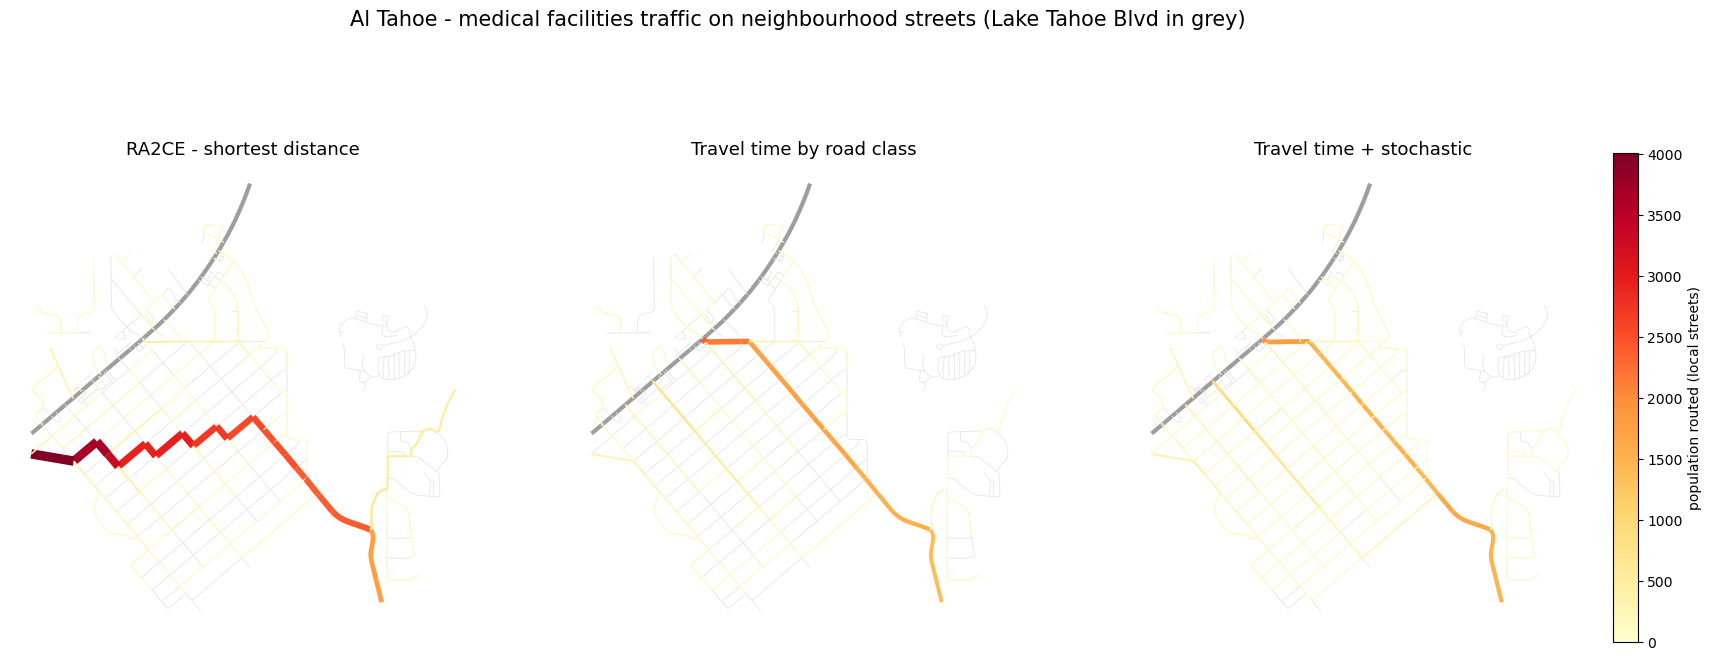

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8), sharex=True, sharey=True)
view = segs_m.loc[near]
arterial = cmp["class"].reindex(view.index).isin(["trunk", "primary", "motorway"]).to_numpy()
local = view[~arterial]
# colour scale set by the neighbourhood streets; the highway would otherwise wash them out
vmax = float(cmp.loc[local.index, ["ra2ce_distance", "time_only", "time_stochastic"]].max().max())
for ax, col, title in zip(axes, ["ra2ce_distance", "time_only", "time_stochastic"],
                          ["RA2CE - shortest distance", "Travel time by road class", "Travel time + stochastic"]):
    view[arterial].plot(ax=ax, color="#9e9e9e", linewidth=3)
    v = cmp[col].reindex(local.index).fillna(0)
    local.plot(ax=ax, color="#e6e6e6", linewidth=0.6)
    on = v > 0
    lw = 0.8 + 6 * np.clip(v[on] / vmax, 0, 1)
    local[on].assign(v=v[on]).plot(ax=ax, column="v", cmap="YlOrRd", vmin=0, vmax=vmax, linewidth=lw)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(0, vmax))
fig.colorbar(sm, ax=axes, fraction=0.015, pad=0.01, label="population routed (local streets)")
label = DEMO.replace("_", " ")
fig.suptitle(f"Al Tahoe - {label} traffic on neighbourhood streets (Lake Tahoe Blvd in grey)", fontsize=15)
fig.savefig(OUT / f"al_tahoe_{DEMO}_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Basin-wide effect

How much traffic moves onto the road hierarchy, and how concentrated it is. "Share of person-km by class"
is each class's share of traffic x segment length.

In [11]:
rows = []
for suffix, (disk, mode) in ANALYSES.items():
    old = gpd.read_file(ODR / f"{disk}_criticality.gpkg", ignore_geometry=True).set_index("rfid_c")["traffic"]
    new = segment_frame(suffix, RESULTS[suffix]["mean"])["t"]
    for label, s in (("ra2ce_distance", old.reindex(seg.index).fillna(0)), ("time_stochastic", new)):
        pk = (s * seg.len_m).groupby(seg["class"]).sum()
        rows.append(dict(analysis=suffix, method=label,
                         **(100 * pk / pk.sum()).round(1).reindex(
                             ["trunk", "primary", "secondary", "tertiary", "residential", "unclassified", "service"]).to_dict(),
                         segments_with_traffic=int((s > 0).sum())))
pd.DataFrame(rows).set_index(["analysis", "method"])

trunk  primary  secondary  tertiary  residential  unclassified  service  segments_with_traffic
analysis           method                                                                                                         
evacuation         ra2ce_distance    31.4     51.1        5.9       2.9          7.0           0.8      0.9                   7529
                   time_stochastic   36.2     49.9        5.5       3.0          4.4           0.7      0.4                   9899
law_enforcement    ra2ce_distance    23.9     24.9       13.4      11.3         16.3           2.5      7.5                   7570
                   time_stochastic   27.8     27.5       14.2      11.2         12.1           2.0      5.1                   9810
medical_facilities ra2ce_distance    23.2     47.8        8.1       6.4         10.4           1.3      2.6                   8764
                   time_stochastic   29.6     49.0        5.5       6.8          6.6           0.9      1.3                  10157
emergency_shelters ra2ce_distance    27.6     29.0       12.9       8.5         12.8           3.6      5.4                   9147
                   time_stochastic   36.7     31.7        8.1       9.1          8.1           2.7      3.5                  10333

## 9. Write outputs

Per analysis, `output/od_stochastic/<analysis>_criticality.gpkg` with the RA2CE criticality schema
(`traffic`, `traffic_egalitarian`, `traffic_prioritarian`, `routed`, `par_alt`) plus `traffic_sd`
(draw-to-draw standard deviation). Then the same two steps as the RA2CE method, pointed at these files:

* `tahoe_od_criticality_combined_stochastic.gpkg` - the four layers merged on `rfid_c`
  (same columns as `tahoe_od_criticality_combined_v2.gpkg`);
* `protect_va_update/protect_va_od_update_stochastic.csv` - the 18,285-street update table, built with
  `export_protect_va.build_update` (two-sided, endpoint-trimmed join) without modifying that script.

`routed` = carried flow in at least one draw. `par_alt` = lies only on parallel edges that are never the
fastest of their node pair at zero noise and carried no flow in any draw.

In [12]:
METRICS = {"traffic": 0, "traffic_egalitarian": 1, "traffic_prioritarian": 2}
combined = bn[["rfid_c", "rfid", "node_A", "node_B", "edge_fid", "length", "geometry"]].copy()
combined = combined.sort_values("rfid_c").reset_index(drop=True)

for suffix, (disk, mode) in ANALYSES.items():
    A, R = DATA[suffix], RESULTS[suffix]
    e = A["edges"]
    mean = R["mean"]
    s = to_segments(A, mean).reindex(seg.index)
    sd = to_segments(A, np.vstack([R["sd"], R["sd"], R["sd"]]))["t"].reindex(seg.index)

    carrier = np.zeros(len(e), bool)
    carrier[cheapest_parallel(e.ui.to_numpy(), e.vi.to_numpy(), e.time_s.to_numpy())] = True
    carrier |= (e.ui == e.vi).to_numpy()     # a self-loop is its own pair, not a parallel alternative
    carrier |= mean[1] > 0
    ex = pd.DataFrame({"segs": e["segs"], "c": carrier}).explode("segs").dropna()
    ex["segs"] = ex["segs"].astype(int)
    any_carrier = ex.groupby("segs")["c"].max().reindex(seg.index).fillna(False).astype(bool)
    named = ex.groupby("segs").size().reindex(seg.index).notna().astype(bool)

    out = bn[["rfid_c", "rfid", "node_A", "node_B", "edge_fid", "length", "time", "geometry"]].copy()
    out = out.set_index("rfid_c")
    out["class"] = seg["class"]
    out["mph"] = seg["mph"]
    out["traffic"] = s["t"].fillna(0)
    out["traffic_egalitarian"] = s["g"].fillna(0)
    out["traffic_prioritarian"] = s["p"].fillna(0)
    out["traffic_sd"] = sd.fillna(0)
    out["routed"] = (s["g"].fillna(0) > 0).astype(int)
    out["par_alt"] = (named & ~any_carrier & (out["routed"] == 0)).astype(int)
    out = out.reset_index()
    out.to_file(OUT / f"{disk}_criticality.gpkg", driver="GPKG", layer=f"{disk}_criticality")

    out = out.sort_values("rfid_c").reset_index(drop=True)
    assert (out.rfid_c.to_numpy() == combined.rfid_c.to_numpy()).all()
    for metric, src in [("traffic", "traffic"), ("egalitarian", "traffic_egalitarian"),
                        ("prioritarian", "traffic_prioritarian"), ("routed", "routed"), ("par_alt", "par_alt")]:
        combined[f"{metric}_{suffix}"] = out[src].to_numpy()
    print(f"{suffix:<20} {int(out.routed.sum()):,} routed segments, {int(out.par_alt.sum()):,} par_alt")

COMBINED_STOCH = OUT / "tahoe_od_criticality_combined_stochastic.gpkg"
combined.to_file(COMBINED_STOCH, driver="GPKG")
print(f"wrote {COMBINED_STOCH.name}")

C:\Users\amcclary\AppData\Local\Temp\ipykernel_121048\1778704069.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  any_carrier = ex.groupby("segs")["c"].max().reindex(seg.index).fillna(False).astype(bool)


evacuation           10,049 routed segments, 4,153 par_alt


C:\Users\amcclary\AppData\Local\Temp\ipykernel_121048\1778704069.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  any_carrier = ex.groupby("segs")["c"].max().reindex(seg.index).fillna(False).astype(bool)


law_enforcement      9,991 routed segments, 4,147 par_alt


C:\Users\amcclary\AppData\Local\Temp\ipykernel_121048\1778704069.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  any_carrier = ex.groupby("segs")["c"].max().reindex(seg.index).fillna(False).astype(bool)


medical_facilities   10,303 routed segments, 4,144 par_alt


C:\Users\amcclary\AppData\Local\Temp\ipykernel_121048\1778704069.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  any_carrier = ex.groupby("segs")["c"].max().reindex(seg.index).fillna(False).astype(bool)


emergency_shelters   10,478 routed segments, 4,139 par_alt


wrote tahoe_od_criticality_combined_stochastic.gpkg


In [13]:
import sys
sys.path.insert(0, str(HERE))
import export_protect_va as epv

epv.COMBINED = COMBINED_STOCH          # module attribute only; the script on disk is unchanged
pub = epv.fetch_published()
upd, pub = epv.build_update(pub)
(OUT / "protect_va_update").mkdir(exist_ok=True)
upd.to_csv(OUT / "protect_va_update" / "protect_va_od_update_stochastic.csv", index=False)
qa = epv.report(upd, pub).replace("this update (ra2ce_v2)", "this update (stochastic)")
(OUT / "protect_va_update" / "protect_va_od_update_stochastic_qa.txt").write_text(qa, encoding="utf-8")

ra2ce_upd = pd.read_csv(HERE / "output" / "protect_va_update" / "protect_va_od_update.csv").set_index("OBJECTID")
cmp_cols = [c for c in ra2ce_upd.columns if c.startswith("traffic_")]
s_upd = upd.set_index("OBJECTID")
pd.DataFrame({c: {"corr_vs_ra2ce": s_upd[c].corr(ra2ce_upd[c]),
                  "streets_>0_ra2ce": int((ra2ce_upd[c] > 0).sum()),
                  "streets_>0_stochastic": int((s_upd[c] > 0).sum())} for c in cmp_cols}).T.round(3)

published layer: 18,285 features (cached)


criticality network: 97,814 rows


  joined 18,285/18,285  (13s)      


PROTECT_VA OD update - QA
features: 18,285

NULL traffic_medical_facilities:
  published (scripts/ra2ce)  : 388
  this update (ra2ce_v2)     : 0
  recovered                  : 388

coverage of each street by criticality rows:
  >=95%      : 18,285 (100.0%)
  50-95%     : 0
  1-50%      : 0
  0% (NULL)  : 0

streets built from more than one criticality row: 1,759
  contributing rows agree exactly on traffic : 1,155
  disagree by >5% of the largest value       : 586
  disagree by >20%                           : 562
  (values are length-weighted means; check od_row_spread_pct before
   quoting a single figure for one of these streets)

traffic > 0 counts, published -> update:
  traffic_evacuation                   7,084 ->   9,629  (+2,545)
  traffic_law_enforcement              7,094 ->   9,568  (+2,474)
  traffic_medical_facilities           8,198 ->   9,874  (+1,676)
  traffic_emergency_shelters           8,605 ->  10,008  (+1,403)

total routed population, published -> update:
  traf

,corr_vs_ra2ce,streets_>0_ra2ce,streets_>0_stochastic
traffic_evacuation,0.958,7364.0,9629.0
traffic_law_enforcement,0.896,7365.0,9568.0
traffic_medical_facilities,0.942,8503.0,9874.0
traffic_emergency_shelters,0.922,8884.0,10008.0


In [14]:
config = dict(method="travel-time routing + stochastic assignment", speeds_mph=SPEED_MPH,
              default_mph=DEFAULT_MPH, n_draws=N_DRAWS, sigma=SIGMA, seed=SEED,
              gravity_beta=GRAVITY_BETA, analyses={k: v[1] for k, v in ANALYSES.items()},
              inputs=str(ODR), validation=valid.to_dict(orient="records"))
(OUT / "run_config.json").write_text(json.dumps(config, indent=2, default=float), encoding="utf-8")
print("wrote run_config.json")

wrote run_config.json
